In [2]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


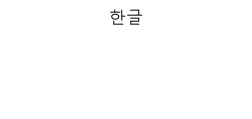

In [3]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [4]:
base_dir = "./chest_xray"
if not os.path.isdir(base_dir):
    print("데이터없음")
else:
    for split in ["train", "test"]:
        for cls in ["NORMAL", "PNEUMONIA"]:
            p = os.path.join(base_dir, split, cls)
            print(f"{split}/{cls:10s}: {len(os.listdir(p)):5d}장")

train/NORMAL    :  1341장
train/PNEUMONIA :  3875장
test/NORMAL    :   242장
test/PNEUMONIA :   398장


In [5]:
batch_size = 32
image_size = 224
learning_rate = 5e-4
epochs = 2
class_labels = ["NORMAL", "PNEUMONIA"]

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([transforms.Resize((image_size, image_size)),
                              transforms.RandomAffine(degrees=0,
                                                      translate=(0.1, 0.1),
                                                      scale=(0.9, 1.1)),
                              transforms.RandomHorizontalFlip(),
                              transforms.ToTensor(),
                              transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

eval_tf = transforms.Compose([transforms.Resize((image_size, image_size)),
                             transforms.ToTensor(),
                             transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

In [7]:
train_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = train_tf)
val_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = eval_tf)
test_set = datasets.ImageFolder(os.path.join(base_dir, "test"), transform = eval_tf)

print(train_full.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [8]:
n_total = len(train_full)
n_val = int(n_total * 0.2)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator = g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = Subset(train_full, train_idx)
val_set = Subset(val_full, val_idx)

train_loader = DataLoader(train_set,
                          batch_size = batch_size,
                          shuffle = True)
val_loader = DataLoader(val_set,
                        batch_size = batch_size,
                        shuffle = False)
test_loader = DataLoader(test_set,
                         batch_size = batch_size,
                         shuffle = False)

print(len(train_set), len(val_set), len(test_set))

4173 1043 640


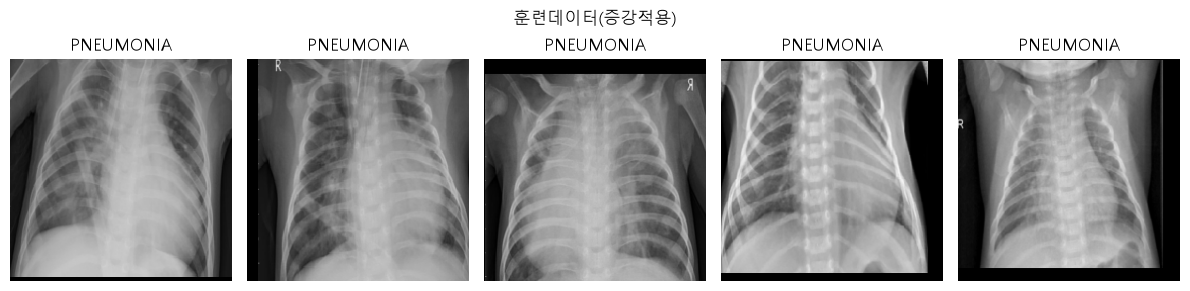

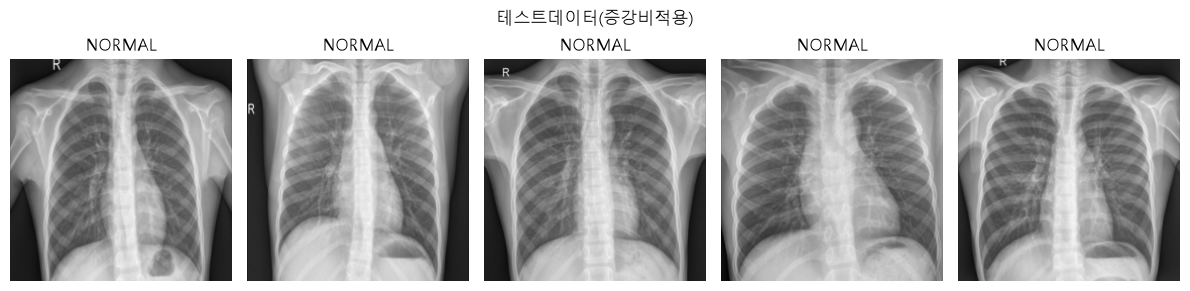

In [9]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)


def show_images(loader, num_images=5, title=""):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
        plt.title(class_labels[int(labels[i])])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(train_loader, title="훈련데이터(증강적용)")
show_images(test_loader, title="테스트데이터(증강비적용)")

In [10]:
# ResNet 을 이용한 전이학습

import timm

class XrayNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("resnetv2_50",
                                          pretrained=pretrained,
                                          num_classes=0,
                                          global_pool="avg")
        n_feat = self.backbone.num_features

        self.head = nn.Sequential(nn.Linear(n_feat, 128),
                                  nn.ReLU(inplace=True),
                                  nn.Dropout(0.1),
                                  nn.Linear(128, 1))

    def forward(self, x):
        return self.head(self.backbone(x))


model = XrayNet(pretrained=True)
with torch.no_grad():
    out = model(torch.zeros(2, 3, image_size, image_size))
print(f"출력 모양 {tuple(out.shape)}")
print(f"파라미터 {sum(p.numel() for p in model.parameters()):,}")

출력 모양 (2, 1)
파라미터 23,762,753


In [11]:
# from sklearn.metrics import (accuracy_score,
#                              recall_score,
#                              precision_score,
#                              roc_auc_score,
#                              confusion_matrix)

# @torch.no_grad()
# def evaluate(model, loader, criterion=None):
#     model.eval()
#     losses, probs, trues = [], [], []

#     for xb, yb in loader:
#         xb, yb = xb.to(device), yb.to(device)
#         logits = model(xb).squeeze(1)

#         if criterion is not None:
#             losses.append(criterion(logits, yb).item() * len(yb))

#         probs.append(torch.sigmoid(logits).cpu().numpy())
#         trues.append(yb.cpu().numpy())

#     probs = np.concatenate(probs)
#     trues = np.concatenate(trues)
#     preds = (probs > 0.5).astype(int)

#     return {"loss" : (sum(losses)) / len(trues) if criterion is not None else None,
#             "accuracy" : accuracy_score(trues, preds),
#             "recall" : recall_score(trues, preds, zero_division = 0),
#             "precision" : precision_score(trues, preds, zero_division = 0),
#             "auc" : roc_auc_score(trues, probs) if len(set(trues)) > 1 else float("nan"),
#             "probs" : probs,
#             "trues" : trues,
#             "preds" : preds}

# def train_model(model,
#                 train_loader,
#                 val_loader,
#                 epochs = 20,
#                 lr = 5e-4,
#                 pos_weight = None,
#                 ckpt_path = "checkpoint.pt",
#                 label = "model"):
#     model = model.to(device)
#     criterion = nn.BCEWithLogitsLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr = lr)

#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min",
#                                                            factor = 0.1,
#                                                            patience = 2,
#                                                            min_lr = 1e-7)
#     history = {k: [] for k in ["loss",
#                                "val_loss",
#                                "accuracy",
#                                "val_accuracy",
#                                "val_recall",
#                                "val_precision",
#                                "val_auc"]}
#     best_val = float("int")

#     for epoch in range(1, epochs + 1):
#         model.train()
#         run_loss, run_correct, n = 0.0, 0, 0
#         t0 = time.time()

#         for xb, yb in train_loader:
#             xb, yb = xb.to(device), yb.to(device)
#             optimizer.zero_grad()
#             logits = model(xb).squeeze(1)
#             loss = criterion(logits, yb)
#             loss.backward()
#             optimizer.step()

#             run_loss += loss.item() * len(yb)
#             run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
#             n += len(yb)

#         tr_loss, tr_acc = run_loss / n, run_correct / n

#         m = evaluate(model, val_loader, criterion)

#         history["loss"].append(tr_loss)
#         history["accuracy"].append(tr_acc)
#         history["val_loss"].append(m["loss"])
#         history["val_accuracy"].append(m["accuracy"])
#         history["val_recall"].append(m["recall"])
#         history["val_precision"].append(m["precision"])
#         history["val_auc"].append(m["auc"])

#         star = ""
#         if m["loss"] > best_val:
#             best_val = m["loss"]
#             torch.save(model.state_dict(), ckpt_path)
#             star = "저장"

#         print(f"[{label}] {epoch:2d} / {epochs}",
#               f"loss {tr_loss:.4f} val_loss {m['loss']:.4f}",
#               f"val_acc {m['accuracy']:.4f} val_auc {m['auc']:.4f}",
#               f"lr {optimizer.param_group[0]["lr"]:.1e}"
#               f"({time.time() - t0:.0f}s) {star}")

#     print(f"best val_loss = {best_val:.4f} {ckpt_path}")
#     return history

In [12]:
from sklearn.metrics import (accuracy_score,
                             recall_score,
                             precision_score,
                             roc_auc_score,
                             confusion_matrix)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).float()
        logits = model(xb).squeeze(1)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = (probs > 0.5).astype(int)

    return {"loss" : (sum(losses)) / len(trues) if criterion is not None else None,
            "accuracy" : accuracy_score(trues, preds),
            "recall" : recall_score(trues, preds, zero_division = 0),
            "precision" : precision_score(trues, preds, zero_division = 0),
            "auc" : roc_auc_score(trues, probs) if len(set(trues)) > 1 else float("nan"),
            "probs" : probs,
            "trues" : trues,
            "preds" : preds}

def train_model(model,
                train_loader,
                val_loader,
                epochs = 20,
                lr = 5e-4,
                pos_weight = None,
                ckpt_path = "checkpoint.pt",
                label = "model"):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min",
                                                           factor = 0.1,
                                                           patience = 2,
                                                           min_lr = 1e-7)
    history = {k: [] for k in ["loss",
                               "val_loss",
                               "accuracy",
                               "val_accuracy",
                               "val_recall",
                               "val_precision",
                               "val_auc"]}
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluate(model, val_loader, criterion)

        history["loss"].append(tr_loss)
        history["accuracy"].append(tr_acc)
        history["val_loss"].append(m["loss"])
        history["val_accuracy"].append(m["accuracy"])
        history["val_recall"].append(m["recall"])
        history["val_precision"].append(m["precision"])
        history["val_auc"].append(m["auc"])

        star = ""
        if m["loss"] < best_val:
            best_val = m["loss"]
            torch.save(model.state_dict(), ckpt_path)
            star = "저장"

        print(f"[{label}] {epoch:2d} / {epochs}",
              f"loss {tr_loss:.4f} val_loss {m['loss']:.4f}",
              f"val_acc {m['accuracy']:.4f} val_auc {m['auc']:.4f}",
              f"lr {optimizer.param_groups[0]['lr']:.1e}",
              f"({time.time() - t0:.0f}s) {star}")

    print(f"best val_loss = {best_val:.4f} {ckpt_path}")
    return history

In [13]:
model = XrayNet(pretrained = True)
history = train_model(model,
                      train_loader, val_loader,
                      epochs = epochs, lr = learning_rate)

[model]  1 / 2 loss 0.2794 val_loss 0.1093 val_acc 0.9597 val_auc 0.9904 lr 5.0e-04 (100s) 저장
[model]  2 / 2 loss 0.1103 val_loss 0.0795 val_acc 0.9732 val_auc 0.9947 lr 5.0e-04 (95s) 저장
best val_loss = 0.0795 checkpoint.pt


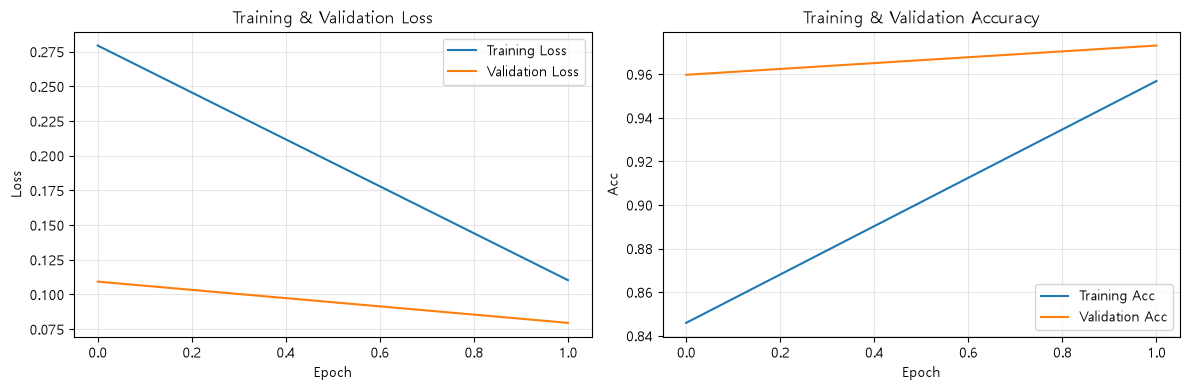

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["accuracy"], label="Training Acc")
plt.plot(history["val_accuracy"], label="Validation Acc")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
best = XrayNet(pretrained = False).to(device)
best.load_state_dict(torch.load("checkpoint.pt", map_location = device))

m = evaluate(best, test_loader)
print(m["accuracy"], m["auc"])

0.8140625 0.9638585489430624


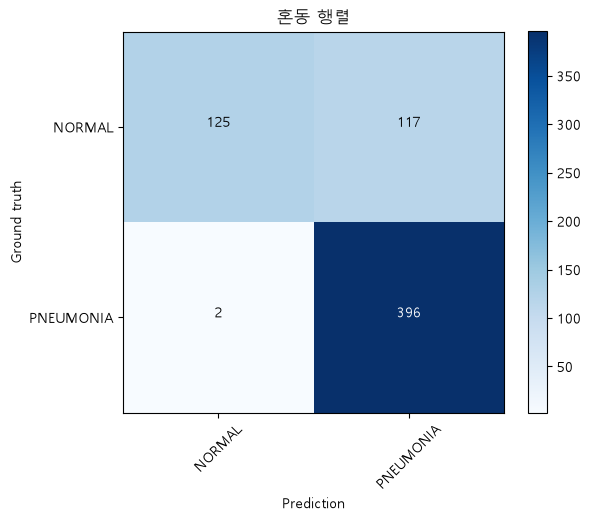

In [16]:
import itertools

def plot_confusion_matrix(cm,
                          classes,
                          normalize = False,
                          title = "혼동 행렬",
                          cmap = plt.cm.Blues):
    plt.imshow(cm, interpolation = "nearest", cmap = cmap)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,
                 i,
                 cm[i, j],
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel("Ground truth")
    plt.xlabel("Prediction")

m = evaluate(model, test_loader)
cm = confusion_matrix(m["trues"], m["preds"])
plt.figure(figsize = (6, 5))
plot_confusion_matrix(cm,
                      classes = class_labels,
                      title = "혼동 행렬")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(m["trues"],
                            m["preds"],
                            target_names = class_labels))

              precision    recall  f1-score   support

      NORMAL       0.98      0.52      0.68       242
   PNEUMONIA       0.77      0.99      0.87       398

    accuracy                           0.81       640
   macro avg       0.88      0.76      0.77       640
weighted avg       0.85      0.81      0.80       640



In [ ]:
from sklearn.metrics import (confusion_matrix,
                             roc_auc_score,
                             balanced_accuracy_score,
                             average_precision_score)

def medical_metrics(trues, preds, probs):
    tn, fp, fn, tp = confusion_matrix(trues, preds).ravel()

    return {"정확도" : (tp + tn) / (tp + tn + fp + fn),
            "균형 정확도" : balanced_accuracy_score(trues, preds),
            "민감도" : tp / (tp + fn) if (tp + fn) else 0.0,
            "특이도" : tn / (tn + fp) if (tn + fp) else 0.0,
            "정밀도" : tp / (tp + fp) if (tp + fp) else 0.0,
            "NPV" : tn / (tn + fn) if (tn + fn) else 0.0,
            "ROC_AUC" : roc_auc_score(trues, probs),
            "PR_AUC" : average_precision_score(trues, probs),
            "_counts" : (tn, fp, fn, tp)}

trues = np.asarray(m["trues"])

res = medical_metrics(trues, m["preds"], m["probs"])
tn, fp, fn, tp = res.pop("_counts")

# 데이터 불균형 확인
n_norm = int((trues == 0).sum())
n_pneu = int((trues == 1).sum())

print(f"정상 {n_norm}, 폐렴 {n_pneu}")
print(f"{n_pneu / (n_norm + n_pneu) * 100:.1f}%")

for k, v in res.items():
    mark = "중요" if k == "민감도" else ""
    print(f"{k:12s} : {v:.4f}{mark}")

print(f"놓친 폐렴 환자 (FN) : {fn}명")
print(f"정상 > 폐렴 오진 (FP) : {fp}명")

정상 242, 폐렴 398
62.2%
정확도          : 0.8141
균형 정확도       : 0.7558
민감도          : 0.9950중요
특이도          : 0.5165
정밀도          : 0.7719
NPV          : 0.9843
ROC_AUC      : 0.9639
PR_AUC       : 0.9771
놓친 폐렴 환자 (FN) : 2명
정상 > 폐렴 오진 (FP) : 117명


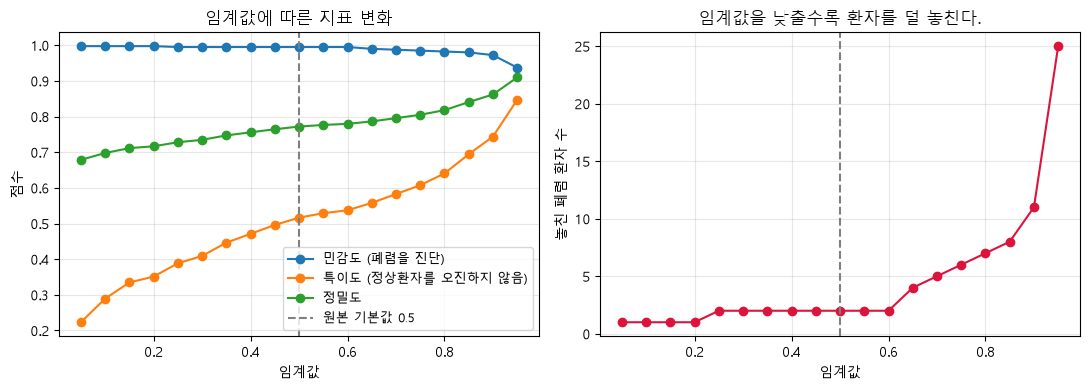

민감도 99% 이상을 만족하는 임계값 중 특이도가 제일 높은 지점
임계값 0.60 -> 민감도 0.9950 특이도 0.5372 놓친 환자 2


In [23]:
# 민감도 조정?
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    p = (m["probs"] > t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(m["trues"],
                                          p,
                                          labels = [0, 1]).ravel()

    rows.append({"threshold": t,
                 "sens" : tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0,
                 "spec" : tn_ / (tn_ + fp_) if (tn_ + fp_) else 0.0,
                 "prec" : tp_ / (tp_ + fp_) if (tp_ + fp_) else 0.0,
                 "fn" : fn_})

plt.figure(figsize = (11, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds,
         [r["sens"] for r in rows],
         "o-",
         label = "민감도 (폐렴을 진단)")
plt.plot(thresholds,
         [r["spec"] for r in rows],
         "o-",
         label = "특이도 (정상환자를 오진하지 않음)")
plt.plot(thresholds,
         [r["prec"] for r in rows],
         "o-",
         label = "정밀도")
plt.axvline(0.5, color = "gray", ls = "--", label = "원본 기본값 0.5")
plt.xlabel("임계값")
plt.ylabel("점수")
plt.legend(fontsize = 9)
plt.grid(alpha = 0.3)
plt.title("임계값에 따른 지표 변화")

plt.subplot(1, 2, 2)
plt.plot(thresholds,
         [r["fn"] for r in rows],
         "o-",
         color = "crimson")
plt.axvline(0.5, color = "gray", ls = "--")
plt.xlabel("임계값")
plt.ylabel("놓친 폐렴 환자 수")
plt.title("임계값을 낮출수록 환자를 덜 놓친다.")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

TARGET = 0.99
candidates = [r for r in rows if r["sens"] >= TARGET]
if candidates:
    chosen = max(candidates, key = lambda r: r["spec"])
    print(f"민감도 {TARGET:.0%} 이상을 만족하는 임계값 중 특이도가 제일 높은 지점")
    print(f"임계값 {chosen['threshold']:.2f} -> 민감도 {chosen['sens']:.4f}",
          f"특이도 {chosen['spec']:.4f} 놓친 환자 {chosen['fn']}")
else:
    print(f"민감도 {TARGET:.0%}를 만족하는 임계값이 없음. 추가 학습 시행")

In [24]:
# 판단 근거 SECTOR 설정하여 판단기준 표시 = CAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None
        self.grads = None
        self.handles = [target_layer.register_forward_hook(self._save_acts),
                        target_layer.register_full_backward_hook(self._save_grads)]

    def _save_acts(self, module, inp, out):
        self.acts = out.detach()

    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()

    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x).squeeze()
        logit.backward()

        weights = self.grads.mean(dim = (2, 3), keepdim = True)
        heat = (weights * self.acts).sum(dim = 1).squeeze(0)
        heat = torch.relu(heat)
        if heat.max() > 0:
            heat = heat / heat.max()
        return heat.cpu().numpy()

    def remove(self):
        for h in self.handles:
            h.remove()

def overlay_heatmap(heat, img01, alpha = 0.4):
    import torch.nn.functional as F
    h = torch.from_numpy(heat)[None, None]
    h = F.interpolate(h, size = img01.shape[:2],
                      mode = "bilinear",
                      align_corners = False)[0, 0].numpy()
    jet = plt.get_cmap("jet")(h)[:, :, :3]
    return np.clip(img01 * (1 - alpha) + jet * alpha, 0, 1)

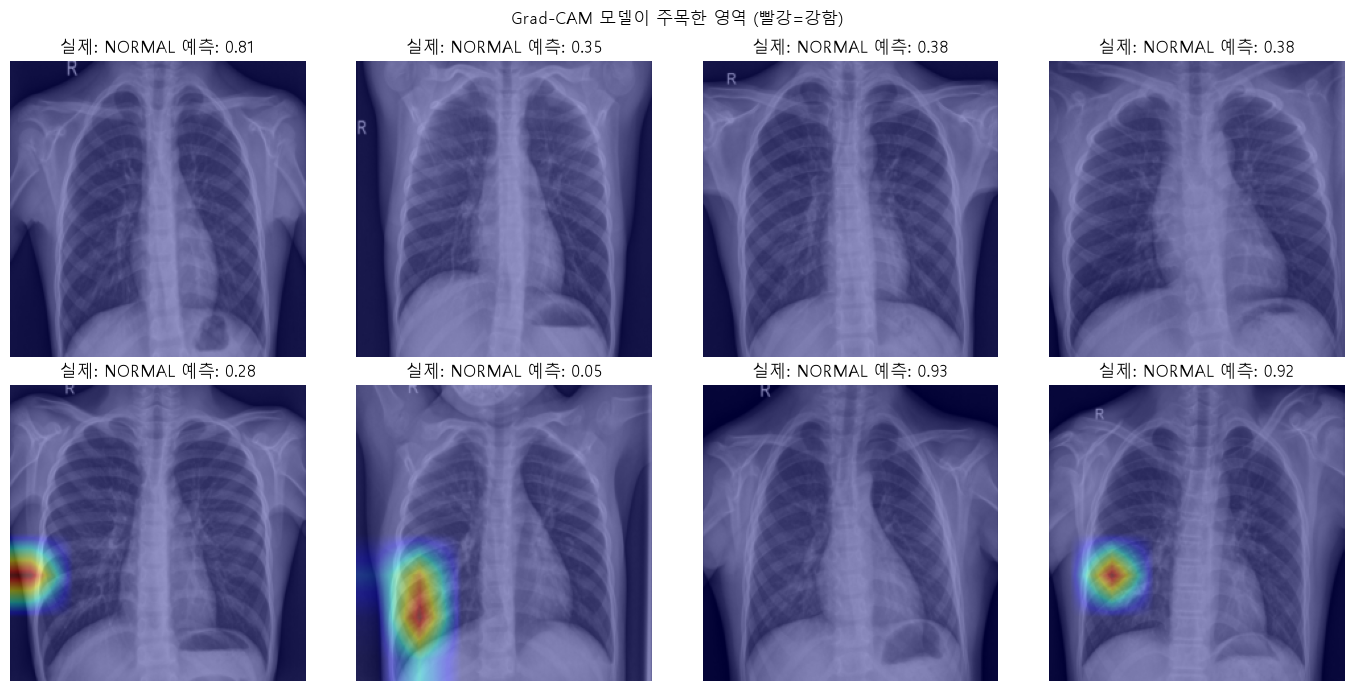

In [25]:
# CAM 시각화

target_layer = best.backbone.stages[-1]
cam = GradCAM(best, target_layer)

fig, ax = plt.subplots(2, 4, figsize =(14, 7))
it = iter(test_loader)
xb, yb = next(it)

for k in range(8):
    i, j = divmod(k, 4)
    x = xb[k:k+1].to(device)
    lab = int(yb[k])

    heat = cam(x)
    img01 = denormalize(xb[k]).permute(1, 2, 0).numpy()

    with torch.no_grad():
        p = torch.sigmoid(best(x)).item()

    ax[i, j].imshow(overlay_heatmap(heat, img01))
    ax[i, j].set_title(f"실제: {class_labels[lab]} 예측: {p:.2f}")
    ax[i, j].axis("off")

cam.remove()
plt.suptitle("Grad-CAM 모델이 주목한 영역 (빨강=강함)")
plt.tight_layout()
plt.show()